In [1]:
import os
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.messages import HumanMessage, ToolMessage

load_dotenv()
if os.getenv("GROQ_API_KEY"):
    print("API Key Loaded")

API Key Loaded


In [2]:
llm = ChatGroq(model = "openai/gpt-oss-120b")

### **Tools**

In [3]:
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper
from langchain_core.tools import tool

@tool
def search_wikipedia(query:str) ->str:
    """This Tool Is For Search In Wikipedia"""
    search = WikipediaQueryRun(api_wrapper = WikipediaAPIWrapper())
    return search.invoke(query)

C:\Users\Samarth\AppData\Local\Temp\ipykernel_8392\1898758127.py:1: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.tools import WikipediaQueryRun


### **Arxiv Query Tool**

In [4]:
from langchain_community.tools import ArxivQueryRun
from langchain_community.utilities import ArxivAPIWrapper
from langchain_core.tools import tool

@tool
def arxiv_tool(query:str) ->str:
    """This Fuction Is For Research Paper Purpose"""
    search = ArxivQueryRun(api_wrapper = ArxivAPIWrapper())
    return search.invoke(query)

### **DuckDuckGo Search**

In [5]:
from langchain_community.tools import DuckDuckGoSearchRun
from langchain_core.tools import tool

@tool
def duckduck_tool(query:str) ->str:
    """This Fuction Is For search on duckduckgo for a latest news Purpose"""
    search = DuckDuckGoSearchRun(description = "This Is For Search On duckduckgo for a latest news")
    return search.invoke(query)

### **Tool Binding**

In [6]:
tools = [search_wikipedia,arxiv_tool,duckduck_tool]
llm_with_tools = llm.bind_tools(tools)

### **LangGraph Creation**

### Create Schema

In [7]:
from typing import TypedDict, List

class graph_schema(TypedDict):
    messages:List

### Create Node Function

In [8]:
def llm_node(state:graph_schema) ->graph_schema:
    messages = state["messages"]
    
    prompt = ChatPromptTemplate.from_messages(
        [
            ("system","You Are A HelpFull Assistant That Can Use Tools To Answer Questions"),
            ("human","{input}")
        ]
    )
    
    chain = prompt | llm_with_tools
    response = chain.invoke({"input":messages})
    
    state["messages"] = messages + [response]
    
    return state

In [9]:
# from langgraph.prebuilt import ToolNode

def tool_node(state:graph_schema) ->graph_schema:
    messages = state["messages"]
    
    tools_by_name = {tool.name:tool for tool in tools}
    
    tool_results = []
    
    for tool_call in messages[-1].tool_calls:
        tool = tools_by_name[tool_call["name"]]
        
        observation = tool.invoke(tool_call["args"])
        
        tool_results.append(ToolMessage(content = observation, tool_call_id = tool_call["id"]))
    
    state["messages"] = messages + tool_results
    return state

### Create Conditional Edge Function

In [10]:
from langgraph.graph import StateGraph, START, END

def if_tool_call(state:graph_schema) ->graph_schema:
    last_message = state['messages'][-1]
    
    if last_message.tool_calls:
        return "tool_node"
    else:
        return "end"

### Create State Graph

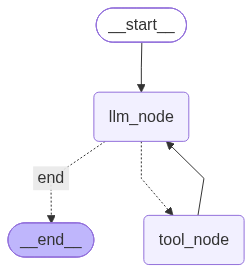

In [11]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("llm_node",llm_node)
graph.add_node("tool_node",tool_node)

graph.add_edge(START, "llm_node")
graph.add_conditional_edges("llm_node",if_tool_call,{"tool_node":"tool_node","end":END})
graph.add_edge("tool_node","llm_node")
graph.add_edge("llm_node",END)

react_graph = graph.compile()
react_graph

### Graph Invocation

In [19]:
react_graph.invoke({"messages": ["Give me latest news on AI","Who is Elon Musk"]})

{'messages': ['Give me latest news on AI',
  'Who is Elon Musk',
  AIMessage(content='', additional_kwargs={'reasoning_content': 'The user gave a list of two queries: "Give me latest news on AI", "Who is Elon Musk". We need to respond with the latest news on AI (likely using duckduck_tool for news) and answer who Elon Musk is (maybe using Wikipedia). Use tools accordingly.\n\nWe should call duckduck_tool with query "latest AI news". Then also call search_wikipedia for "Elon Musk". Then compile answer.', 'tool_calls': [{'id': 'fc_b9454256-fc43-41de-9870-f499b730e63d', 'function': {'arguments': '{"query":"latest AI news"}', 'name': 'duckduck_tool'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 118, 'prompt_tokens': 210, 'total_tokens': 328, 'completion_time': 0.249332249, 'completion_tokens_details': {'reasoning_tokens': 87}, 'prompt_time': 0.008996385, 'prompt_tokens_details': None, 'queue_time': 0.278777973, 'total_time': 0.258328634}, 'model_name': 'o